### Run model with B3 t cells (no velocity)
- use treeHMM_env

In [1]:
import sys
import os
import importlib

os.chdir("/gladstone/engelhardt/lab/jutran/lci/treeHMM")

import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal

from utils import generate_tree_hmm_data
from utils import visualize_lineage

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from dynamax.hidden_markov_model import LinearAutoregressiveHMM
from models.tarhmm import tARHMM
from dynamax.utils.plotting import gradient_cmap
from dynamax.utils.utils import random_rotation
#from dynamax.hidden_markov_model.models.tarhmm import tree_hmm_backward_filter
from typing import Callable, Optional
from dynamax.types import IntScalar, Float, Array

# module import version sanity check
hasattr(jax.interpreters.xla, 'pytype_aval_mappings')

from models.tarhmm import tree_hmm_two_filter_smoother

import pickle

import zipfile
from io import BytesIO
import tifffile

from pathlib import Path
import yaml

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from jax import vmap
from functools import partial


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Visualize num_states

In [10]:
emission_dim = 2

In [3]:
emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_600x600_well/batched_B3_emissions_array.npy")
emissions.shape

(1, 250, 1722, 3)

In [9]:
emissions = emissions[:,:,:, 1:]
emissions.shape

(1, 250, 1722, 2)

In [11]:
num_states = list(range(2, 15))
results = []

for state in num_states:
    num_states = state
    num_lags = 1

    transition_matrix = jnp.eye(num_states) * 0.85 + (1 - jnp.eye(num_states)) * 0.075

    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_600x600_well/batched_B3_data.pkl", "rb") as f:
        data = pickle.load(f)
    
    with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_600x600_well/batched_B3_well_and_cell_id_to_col.pkl", "rb") as f:
        well_and_cell_id_to_col = pickle.load(f)

    arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
    params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions, transition_matrix = transition_matrix)
    inputs = vmap(arhmm.compute_inputs)(
        jnp.array(emissions),
        jnp.array(data["parent_indices"]),
        jnp.array(data["is_division_mask"]),
        jnp.array(data["is_new_root_mask"]),
        jnp.array(data["active_mask"]),
    )

    # TODO: maybe fix this???
    batched_emissions = emissions
    batched_inputs = inputs
    batched_parent_indices = data["parent_indices"]
    batched_is_division_mask = data["is_division_mask"]
    batched_active_mask = data["active_mask"]
    batched_is_new_root_mask = data["is_new_root_mask"]

    fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
    parent_indices=batched_parent_indices,
    is_division_mask=batched_is_division_mask,
    active_mask=batched_active_mask,
    is_new_root_mask=batched_is_new_root_mask)

    results.append((np.mean(lps), lps))


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:02&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:03&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:03&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:04&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:05&lt;00:00]</div>

...

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:07&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:07&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:08&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:08&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:10&lt;00:00]</div>

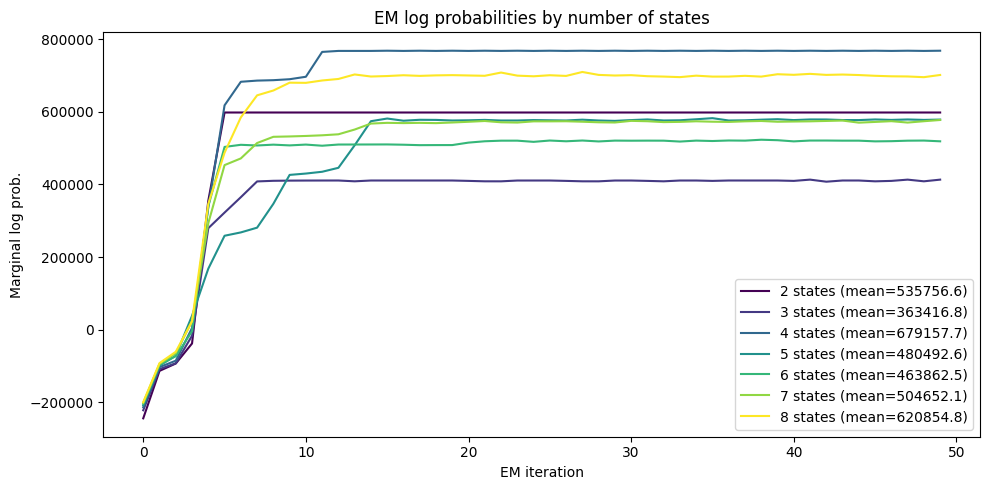

In [24]:
state_range = list(range(2, 9))
cmap = plt.cm.viridis
colors = [cmap(i / (len(state_range) - 1)) for i in range(len(state_range))]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (mean_lp, lps) in enumerate(results[:len(state_range)]):
    n = state_range[i]
    ax.plot(lps, color=colors[i], label=f"{n} states (mean={mean_lp:.1f})")

ax.set_xlabel("EM iteration")
ax.set_ylabel("Marginal log prob.")
ax.set_title("EM log probabilities by number of states")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The most meaningful jump happens when states = 4, so run a model with 4 states.

### Run model on well B3

In [20]:
emissions = np.load("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_600x600_well/batched_B3_emissions_array.npy")
emissions = emissions[:,:,:, 1:]

with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_600x600_well/batched_B3_data.pkl", "rb") as f:
    data = pickle.load(f)

with open("/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_600x600_well/batched_B3_well_and_cell_id_to_col.pkl", "rb") as f:
    well_and_cell_id_to_col = pickle.load(f)


In [21]:
num_states = 4
emission_dim = 2

In [22]:
num_lags = 1

transition_matrix = jnp.eye(num_states) * 0.85 + (1 - jnp.eye(num_states)) * 0.075

arhmm = tARHMM(num_states, emission_dim, num_lags=num_lags)
params, props = arhmm.initialize(key=jr.PRNGKey(1), method="kmeans", emissions=emissions, transition_matrix = transition_matrix)
inputs = vmap(arhmm.compute_inputs)(
    jnp.array(emissions),
    jnp.array(data["parent_indices"]),
    jnp.array(data["is_division_mask"]),
    jnp.array(data["is_new_root_mask"]),
    jnp.array(data["active_mask"]),
)

# TODO: maybe fix this???
batched_emissions = emissions
batched_inputs = inputs
batched_parent_indices = data["parent_indices"]
batched_is_division_mask = data["is_division_mask"]
batched_active_mask = data["active_mask"]
batched_is_new_root_mask = data["is_new_root_mask"]

input_fwd = vmap(partial(arhmm._inference_args, params))(batched_emissions, batched_inputs, batched_parent_indices, batched_is_division_mask, batched_active_mask, batched_is_new_root_mask)
initial_posterior = vmap(tree_hmm_two_filter_smoother)(*input_fwd)

fitted_params, lps = arhmm.fit_em(params, props, batched_emissions, inputs=batched_inputs,
parent_indices=batched_parent_indices,
is_division_mask=batched_is_division_mask,
active_mask=batched_active_mask,
is_new_root_mask=batched_is_new_root_mask)

# Compute the posterior distribution of the latent states
# input_fwd = vmap(partial(arhmm._inference_args, params))(emissions, inputs, data['parent_indices'], data['is_division_mask'], data['active_mask'],data['is_new_root_mask'])
input_fwd = vmap(partial(arhmm._inference_args, fitted_params))(batched_emissions, batched_inputs, batched_parent_indices, batched_is_division_mask, batched_active_mask, batched_is_new_root_mask)
posterior = vmap(tree_hmm_two_filter_smoother)(*input_fwd)

# save state assignments
state_assignments = jnp.argmax(posterior.smoothed_probs, axis=-1)  # (50, 110)

data_output_dir = "/gladstone/engelhardt/lab/jutran/lci/treeHMM/notebooks/data/example_600x600_well/"
np.save(os.path.join(data_output_dir, f"batched_B3_state_assignments_{num_states}_states_no_velocity.npy"), state_assignments)

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:03&lt;00:00]</div>

### Visualize outputs

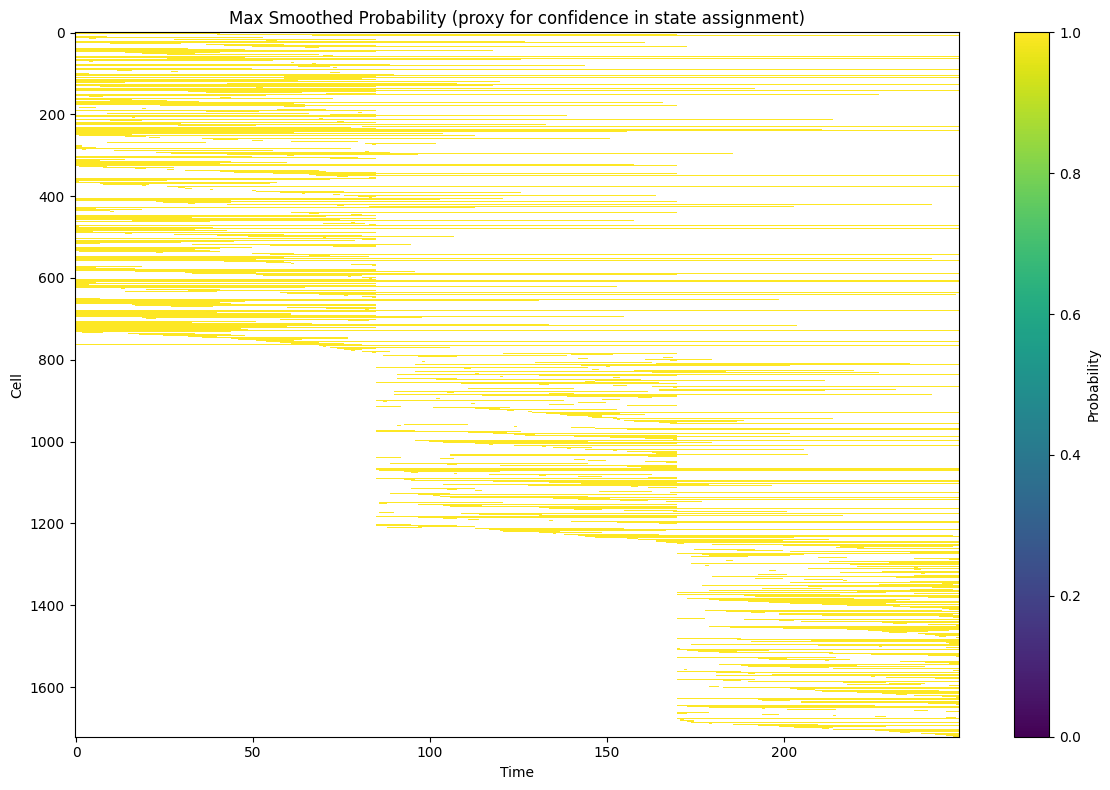

In [33]:
max_probs = jnp.max(posterior.smoothed_probs, axis=-1)  # (50, 326)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(max_probs.T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Max Smoothed Probability (proxy for confidence in state assignment)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

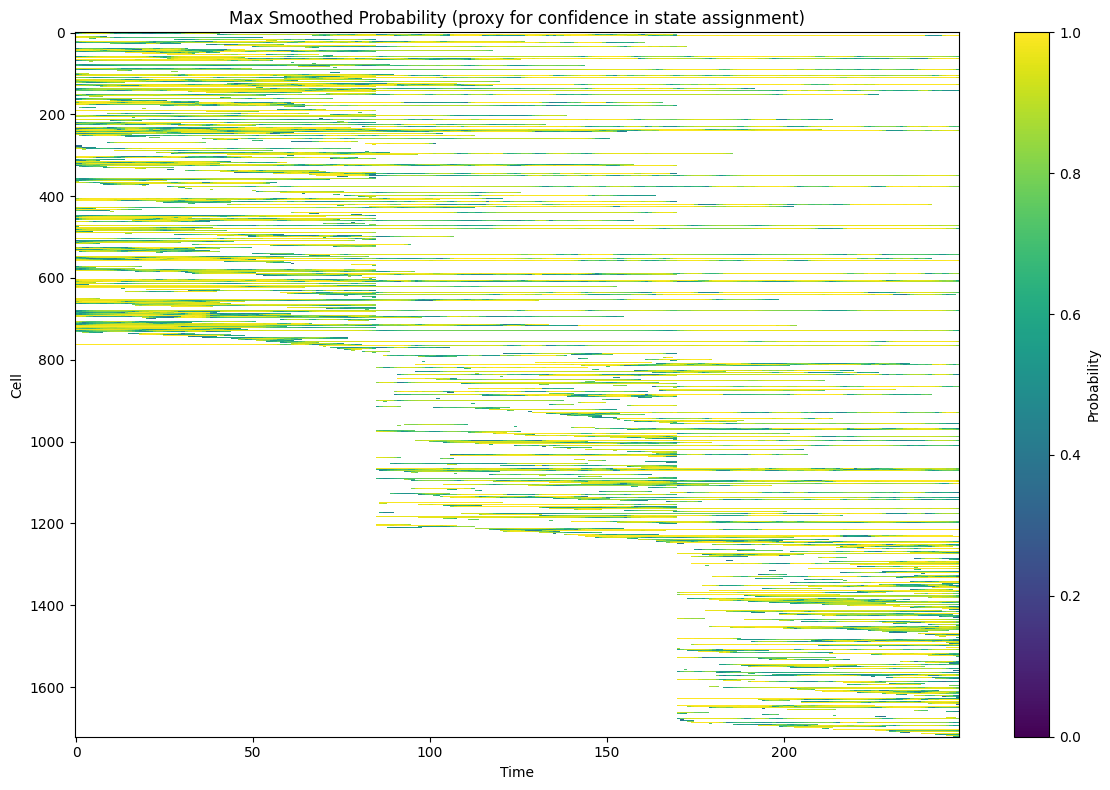

In [32]:
max_probs = jnp.max(initial_posterior.smoothed_probs, axis=-1)  # (50, 326)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(max_probs.T, aspect="auto", interpolation="none", cmap="viridis", origin="upper", vmin=0, vmax=1)
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Max Smoothed Probability (proxy for confidence in state assignment)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")
plt.tight_layout()
plt.show()

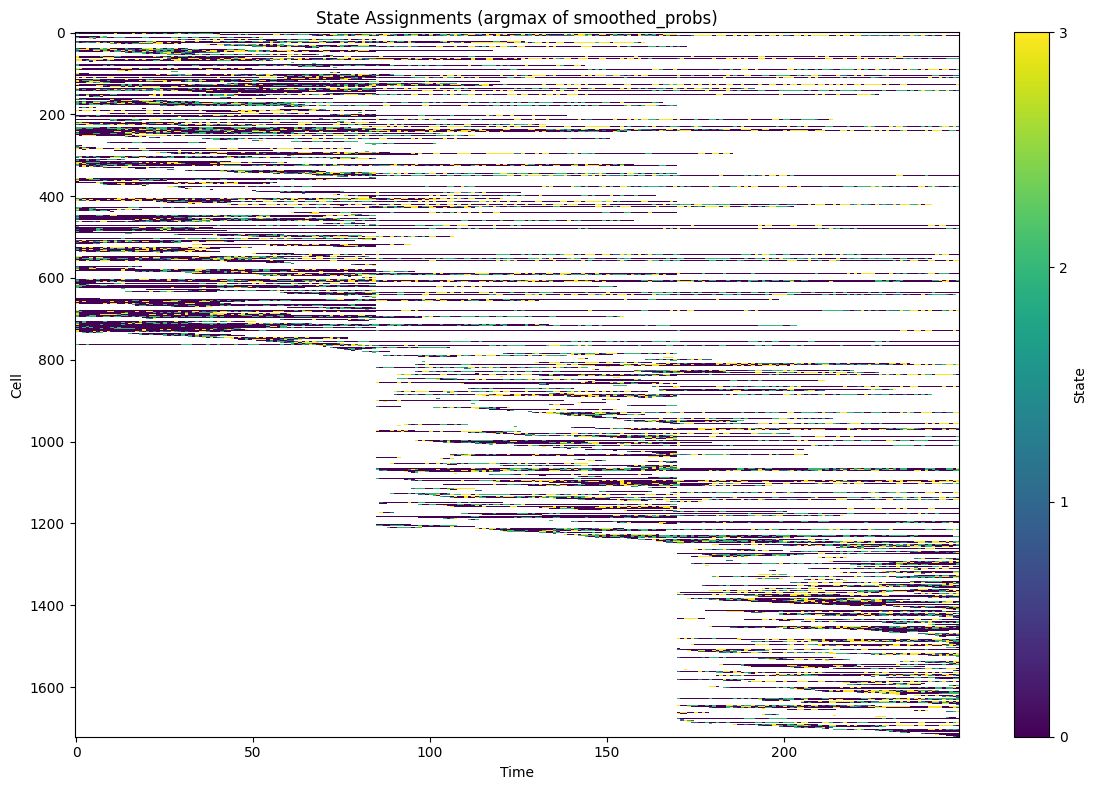

In [26]:
masked_state_assignments = jnp.where(jnp.isnan(max_probs.T), jnp.nan, state_assignments.T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments, aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

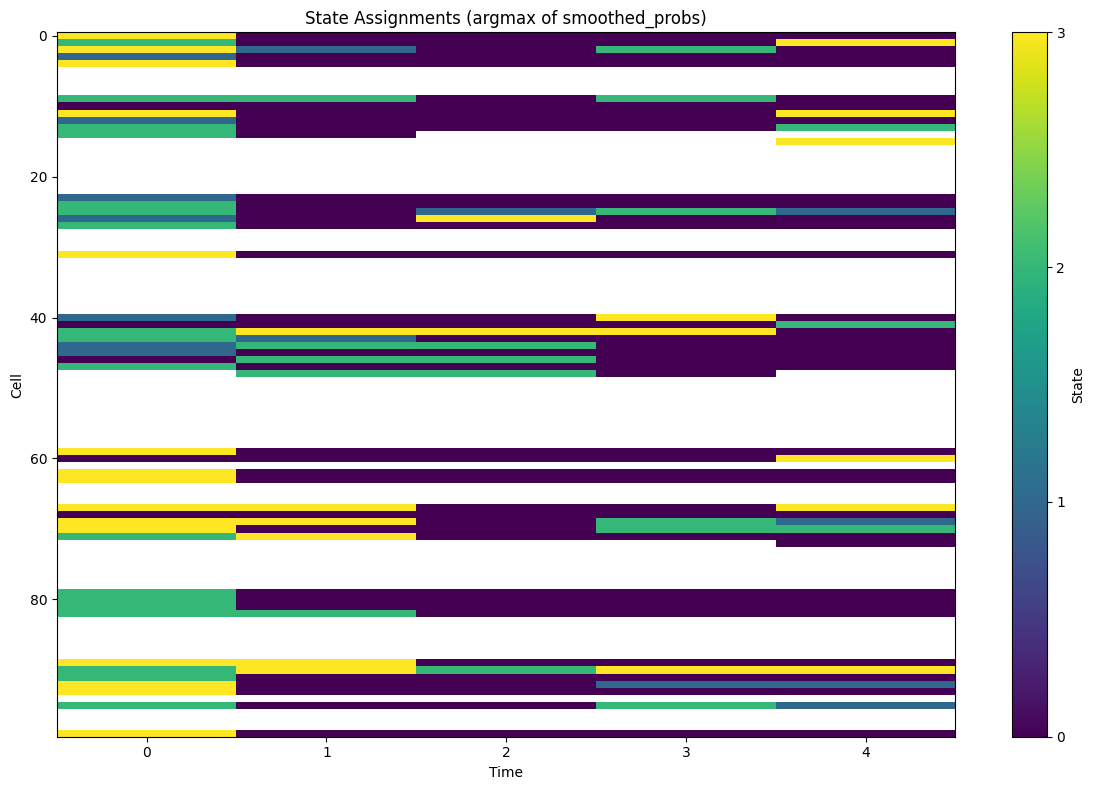

In [27]:
masked_state_assignments = jnp.where(jnp.isnan(max_probs.T), jnp.nan, state_assignments.T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments[:100, :5, :], aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

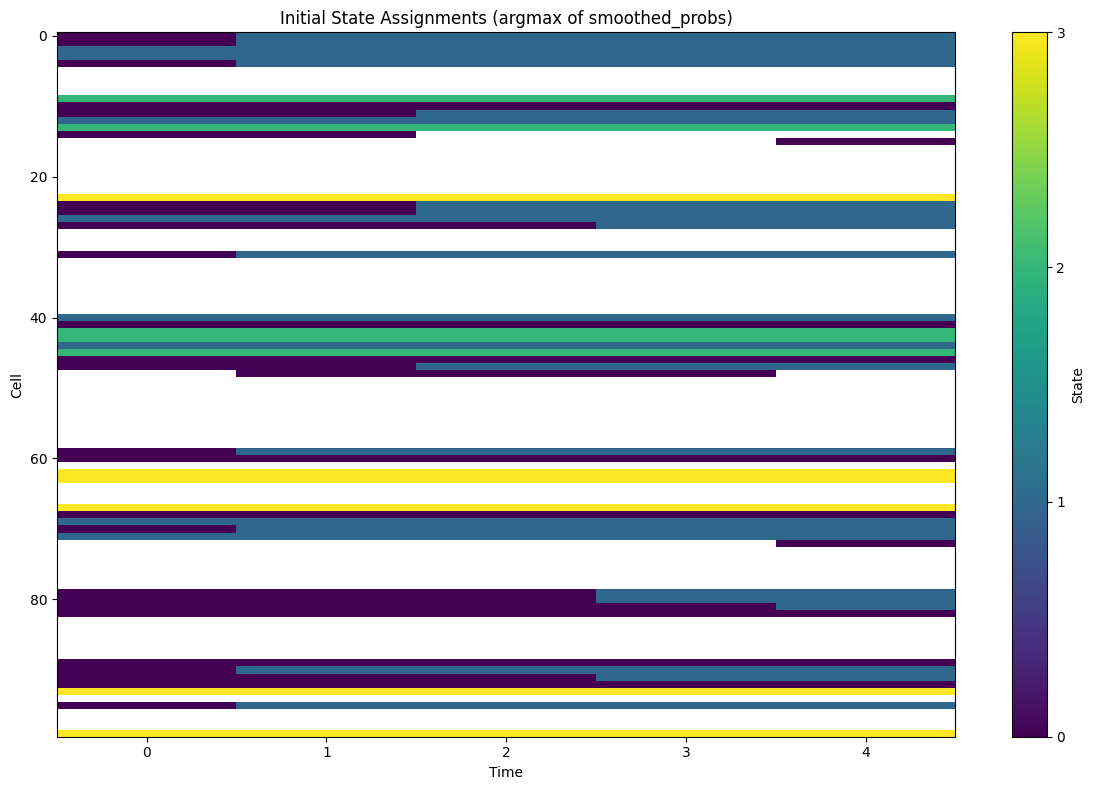

In [29]:
initial_max_probs = jnp.max(initial_posterior.smoothed_probs, axis=-1)  # (50, 326)
initial_state_assignments = jnp.argmax(initial_posterior.smoothed_probs, axis=-1)
masked_state_assignments = jnp.where(jnp.isnan(initial_max_probs.T), jnp.nan, initial_state_assignments.T)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(masked_state_assignments[:100, :5, :], aspect="auto", interpolation="none", cmap="viridis", origin="upper")
ax.set_xlabel("Time")
ax.set_ylabel("Cell")
ax.set_title("Initial State Assignments (argmax of smoothed_probs)")
cbar = plt.colorbar(im, ax=ax, ticks=range(num_states))
cbar.set_label("State")
plt.tight_layout()
plt.show()

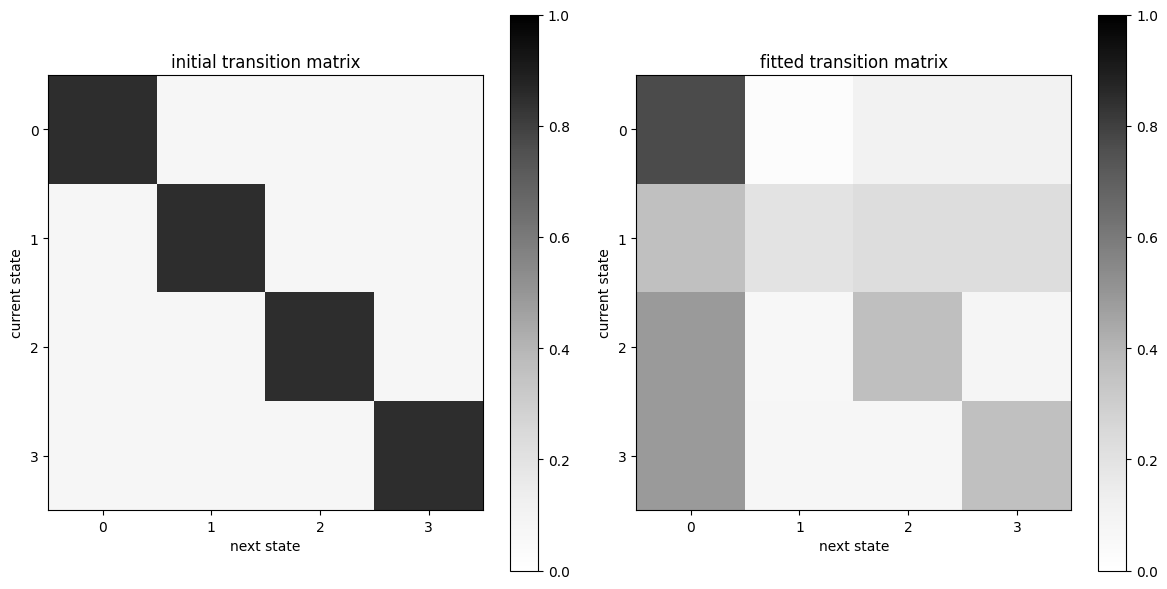

In [37]:
initial_transitions = params.transitions.transition_matrix
fitted_transitions = fitted_params.transitions.transition_matrix

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(initial_transitions, vmin=0, vmax=1, cmap="Greys")
ax[0].set_xlabel("next state")
ax[0].set_ylabel("current state")
ax[0].set_title("initial transition matrix")
ax[0].set_xticks(range(num_states))
ax[0].set_yticks(range(num_states))
plt.colorbar(ax[0].imshow(initial_transitions, vmin=0, vmax=1, cmap="Greys"), ax=ax[0])

ax[1].imshow(fitted_transitions, vmin=0, vmax=1, cmap="Greys")
ax[1].set_xlabel("next state")
ax[1].set_ylabel("current state")
ax[1].set_title("fitted transition matrix")
ax[1].set_xticks(range(num_states))
ax[1].set_yticks(range(num_states))
plt.colorbar(ax[1].imshow(fitted_transitions, vmin=0, vmax=1, cmap="Greys"), ax=ax[1])
plt.tight_layout()
plt.show()


In [38]:
fitted_transitions

Array([[0.7694545 , 0.02075709, 0.10550362, 0.10428479],
       [0.35948107, 0.19336088, 0.22424799, 0.22291008],
       [0.4882529 , 0.06594099, 0.3635886 , 0.08221743],
       [0.48772264, 0.07354055, 0.07560222, 0.3631346 ]], dtype=float32)